In [ ]:
# 案例：TMDB-TOP300 电影榜单数据统计分析
# 需求1：统计TOP300的电影中，每一年上映的电影数量的变化。(折线图)
# 需求2：统计对比不同语言的电影数量(柱状图)
# 需求3：统计对比不同类型类型数量(柱状图)
# 需求4：统计对比各个电影评分的比例（饼状图）

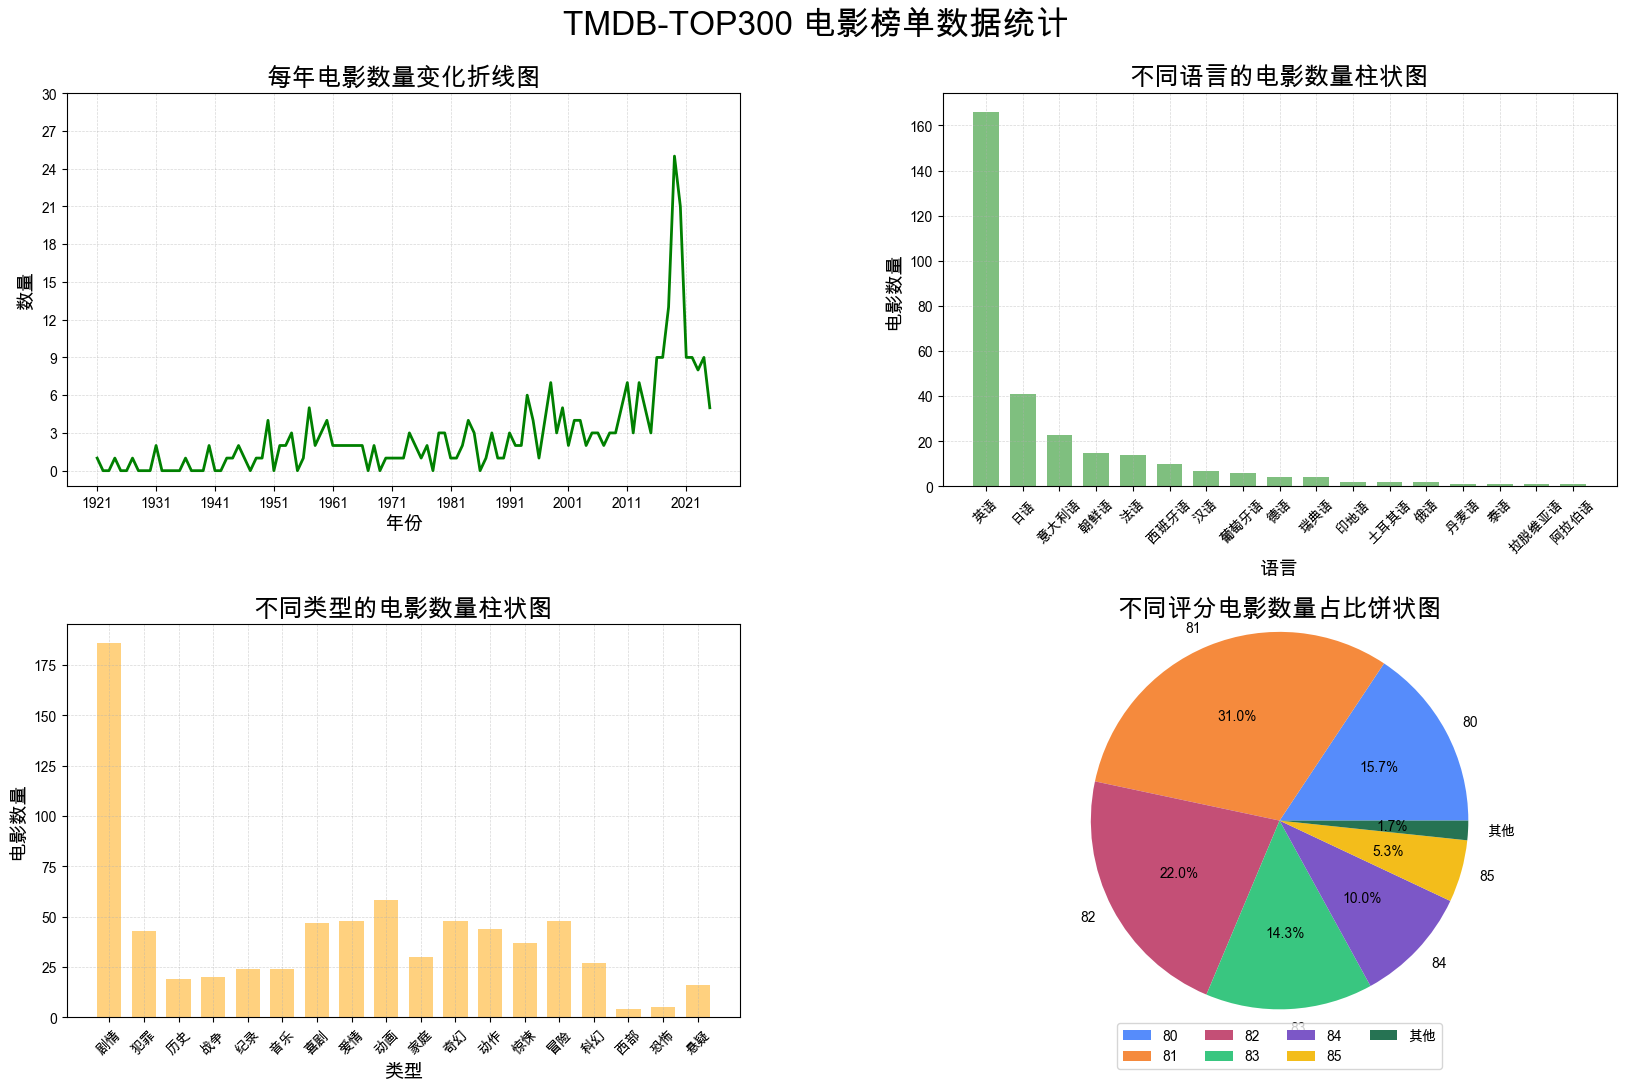

In [100]:
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import pandas as pd

# 准备工作：导入依赖库、配置运行时参数、创建子图完成基本布局、加载数据
# 支持中文
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 12),dpi=100)
# 添加画布标题 x=0.5 控制X轴位置 y=0.95 控制Y轴位置
fig.suptitle('TMDB-TOP300 电影榜单数据统计', fontsize=24,x=0.5,y=0.95)
# 调整子图间距 hspace控制垂直间距 wspace控制水平间距
plt.subplots_adjust(hspace=0.35, wspace=0.3)
axes1:Axes = ax[0][0]
axes2:Axes = ax[0][1]
axes3:Axes = ax[1][0]
axes4:Axes = ax[1][1]

# 加载数据，清洗数据
# int64: 整形数字（不支持空值）
# Int64：整形数字(支持空值)
# float64: 浮点型数字（支持空值）
data = pd.read_csv(
    "data/movies.csv",
    usecols=["年份","电影名","上映时间","类型","时长","评分","语言"],
    dtype={"年份": "Int64"}
)

# 需求1：统计TOP300的电影中，每一年上映的电影数量的变化。(折线图)
# 1.1 缺失值、异常值处理
# data.isnull().sum()
data["年份"] = data["年份"].fillna(data["上映时间"].str[0:4])

# 1.2 分组统计
year_count = data.groupby("年份")["年份"].count()
# 1.3 组装数据（年份连续，补充数据）
# X轴数据
min_year = year_count.index.min()
max_year = year_count.index.max()
x = [i for i in range(min_year, max_year+1)]
y = [year_count.get(i, 0) for i in x]
# 1.4 绘制折线图
axes1.plot(x, y, color="green", linewidth=2)
axes1.set_title("每年电影数量变化折线图", fontsize=18)
axes1.set_xlabel("年份", fontsize=14)
axes1.set_ylabel("数量", fontsize=14)
axes1.set_xticks(x[::10]) # X轴刻度间隔
y_ticks = [i for i in range(0, 31, 3)] # Y轴刻度间隔
axes1.set_yticks(y_ticks)
axes1.grid(linestyle="--", alpha=0.5) #网格

# 需求2：统计对比不同语言的电影数量(柱状图)
# 2.1 获取不同语言对应的电影数量并排序(降序)
lang_count = data.groupby("语言")["语言"].count().sort_values(ascending=False)
# 2.2 绘制柱状图
x_lang = lang_count.index.tolist()
y_lang_count = lang_count.values.tolist()

axes2.bar(x_lang, y_lang_count, width=0.7, alpha=0.5, color="green")
axes2.set_title("不同语言的电影数量柱状图", fontsize=18)
axes2.set_xlabel("语言", fontsize=14)
axes2.set_ylabel("电影数量", fontsize=14)
axes2.grid(alpha=0.5, linestyle="--")
axes2.tick_params(axis="x", rotation=45) # 旋转x轴标签


# 需求3：统计对比不同类型类型数量(柱状图)
# 3.1 准备数据---字典存储方式
type_count = {} #{"剧情":5, "犯罪": 4, "历史": 3}
for types in data["类型"].str.split(","):
    for type in types:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1

x_types = type_count.keys()
y_values = type_count.values()

# 3.2 绘制柱状图
axes3.bar(x_types, y_values,  width=0.7, alpha=0.5, color="orange")
axes3.set_title("不同类型的电影数量柱状图", fontsize=18)
axes3.set_xlabel("类型", fontsize=14)
axes3.set_ylabel("电影数量", fontsize=14)
axes3.grid(alpha=0.5, linestyle="--")
axes3.tick_params(axis="x", rotation=45) # 旋转x轴标签

# 需求4：统计对比各个电影评分的比例（饼状图）
# 4.1 获取不同评分对应的电影数量
score_count = data.groupby("评分")["评分"].count()

# 优化 小比例数据展示不完整 ---> 小比例数据合并(比例 < 2%) --- 其他
total = score_count.sum()
# 阈值（2%），具体根据业务需要设置
large_scores = score_count.loc[score_count >= total * 0.02] # 大数据 比例 >= 2%
small_scores = score_count.loc[score_count < total * 0.02]
if small_scores.shape[0] > 0:
    large_scores["其他"] = small_scores.sum()


scores = large_scores.index.tolist()
scores_values = large_scores.values.tolist()

# 4.2 绘制饼状图 startangle=90 起始角度
axes4.pie(scores_values, labels=scores, autopct="%1.1f%%", startangle=0, radius=1.2)
axes4.set_title("不同评分电影数量占比饼状图", fontsize=18)
axes4.legend(loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.15))

plt.savefig('data/TMDB-TOP300.png')

plt.show()

